In [ ]:
# 경고 처리
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os
import json
import re

# 지리 정보 관련
import geopandas as gpd

# 딥 러닝 및 머신 러닝
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, train_test_split
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.callbacks import EarlyStopping
from keras.utils import plot_model

# 진행 상황 표시
from tqdm.auto import tqdm

# 데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.core.display import display, HTML
import polars as pl

# 데이터 전처리
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 데이터 분석 및 모델 훈련
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline

# 모델 성능 평가
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 딥 러닝 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 초기화 및 콜백
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.callbacks import EarlyStopping

# 모델 시각화
from keras.utils import plot_model

# 시각화 설정
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'D2Coding'



# 시각화 설정
display(HTML("<style>.container { width:100% !important; }</style>"))
pd.set_option('display.max_columns', None)


# Data read

In [2]:
pnt_raw = pd.read_csv('./use_data/result/input/PNT_EQU_RAW_daysum.csv',encoding='cp949')
sct_raw = pd.read_csv('./use_data/result/input/SCT_EQU_RAW_daysum.csv',encoding='cp949')

In [ ]:
pd.read_csv('./use_data/csv/mts_light.csv')

## Data set split
- 단속형태 (신호,과속,구간)
    - 지점단속 
        - 신호위반 334개 장비
        - 속도위반 89개 장비
    - 구간단속
        - 4개 구간
- 지표 (사고, 과속)
    - 사고 :  설치전 1년 (:364 -> 365일)
    - 단속 :  설치후 6개월 (365:547 -> 183일)

||신호|과속|구간|
|--|----|----|----|
|사고|<b>acc_lgt</b> (121910, 23)| <b>acc_spd</b> (32485, 23)|<b>acc_sct</b> (1460, 23)|
|단속|<b>vio_lgt</b> (61122, 27)| <b>vio_spd</b> (16287, 27)|<b>vio_lgt</b> (732, 27)|

In [3]:
#정수 변환
for col in [x for x in pnt_raw.columns if '수' in x and '강수' not in x]:
    pnt_raw[col] = pnt_raw[col].astype('int')
for col in [x for x in sct_raw.columns if '수' in x and '강수' not in x]:
    sct_raw[col] = sct_raw[col].astype('int')
    
#데이터 분할 준비
acc_lgt, acc_spd, acc_sct, vio_lgt, vio_spd, vio_sct  = pd.DataFrame(),pd.DataFrame(),pd.DataFrame(),pd.DataFrame(),pd.DataFrame(),pd.DataFrame()
pnt_acc_col = [x for x in pnt_raw.columns if x not in pnt_raw.columns[range(13,17)]]
pnt_vio_col = pnt_raw.columns
sct_acc_col = [x for x in sct_raw.columns if x not in sct_raw.columns[range(6,10)]]
sct_vio_col = sct_raw.columns

#단속형태별 분할
lgt_df = pnt_raw[pnt_raw['단속형태'] == '신호위반']
spd_df = pnt_raw[pnt_raw['단속형태'] == '속도위반']
sct_df = sct_raw


##신호위반
for idx in tqdm(lgt_df['장비번호'].unique()):
    
    df = lgt_df[lgt_df['장비번호'] == idx]
    df.reset_index(drop=True,inplace=True)
    
    #사고 기간 분할(설치전 1년)
    acc_df = df.loc[:364,pnt_acc_col]
    
    #단속 기간 분할(설치후 6개월)
    vio_df = df.loc[365:547,pnt_vio_col]
    
    #병합
    acc_lgt = pd.concat([acc_lgt,acc_df])
    vio_lgt = pd.concat([vio_lgt,vio_df])
    
##속도위반
for idx in tqdm(spd_df['장비번호'].unique()):
    
    df = spd_df[spd_df['장비번호'] == idx]
    df.reset_index(drop=True,inplace=True)
    
    #사고 기간 분할(설치전 1년)
    acc_df = df.loc[:364,pnt_acc_col]
    
    #단속 기간 분할(설치후 6개월)
    vio_df = df.loc[365:547,pnt_vio_col]
    
    #병합
    acc_spd = pd.concat([acc_spd,acc_df])
    vio_spd = pd.concat([vio_spd,vio_df])

##구간 단속
for gnm in tqdm(sct_raw['구간그룹명'].unique()):
    df = sct_raw[sct_raw['구간그룹명']==gnm]
    df.reset_index(drop=True,inplace=True)
    
    #사고 기간 분할(설치전 1년)
    acc_df = df.loc[:364,sct_acc_col]
    
    #단속 기간 분할(설치후 6개월)
    vio_df = df.loc[365:547,sct_vio_col]
    
    #병합
    acc_sct = pd.concat([acc_sct,acc_df])
    vio_sct = pd.concat([vio_sct,vio_df])

  0%|          | 0/334 [00:00<?, ?it/s]

  0%|          | 0/89 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

# Preprocessing

## 사고/단속 0값 제거

|0개수|신호|과속|구간|
|--|--|--|--|
|사고|**130(39%)**|8(9%)|0(0%)|
|단속|4(1%)|4(4%)|0(0%)|

단속장비 중 사고/단속건이 0건인 장비들은 제외하고 분석에 활용

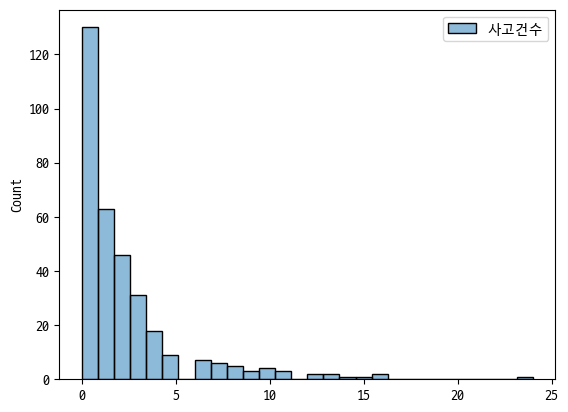

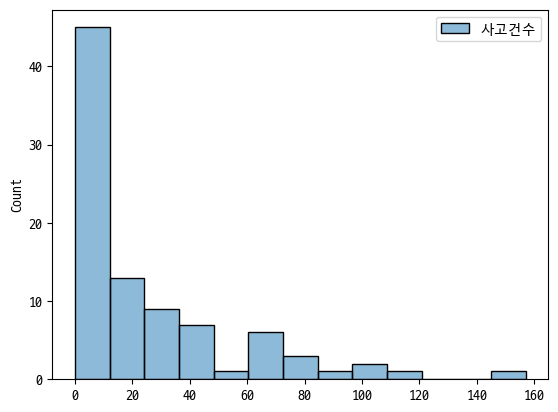

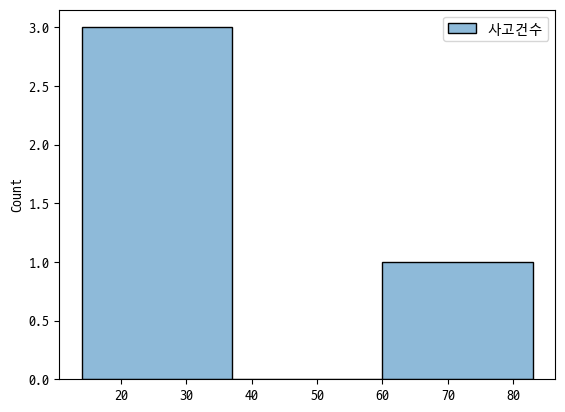

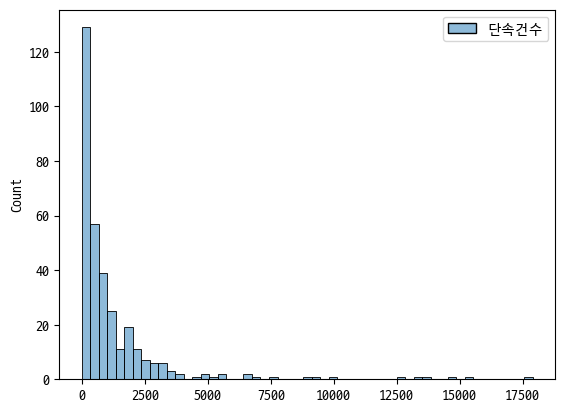

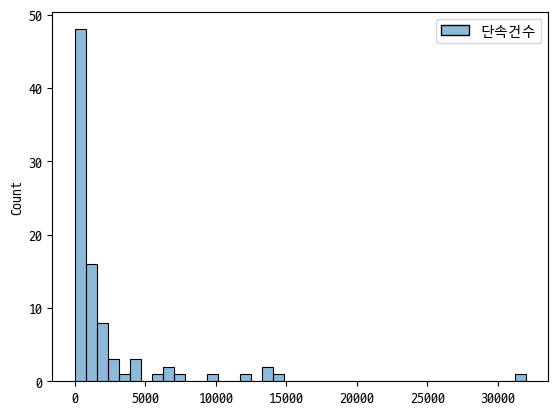

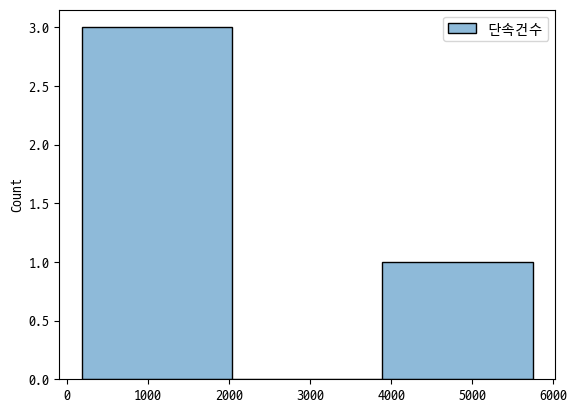

In [4]:
for num,tdf in enumerate([acc_lgt, acc_spd, acc_sct, vio_lgt, vio_spd, vio_sct]):
    if num <= 1:
        sns.histplot(tdf.groupby(['장비번호']).agg({'사고건수':'sum'}))
        plt.show()
    elif num == 2 :
        sns.histplot(tdf.groupby(['구간그룹명']).agg({'사고건수':'sum'}))
        plt.show()
    elif num > 2 and num <= 4:
        sns.histplot(tdf.groupby(['장비번호']).agg({'단속건수':'sum'}))
        plt.show()
    else:
        sns.histplot(tdf.groupby(['구간그룹명']).agg({'단속건수':'sum'}))
        plt.show()

### 0 값 제거 전

In [5]:
dflist = 'acc_lgt, acc_spd, acc_sct, vio_lgt, vio_spd, vio_sct'.split(',')
for num,tdf in enumerate([acc_lgt, acc_spd, acc_sct, vio_lgt, vio_spd, vio_sct]):
    if num <= 1:
        tmp = tdf.groupby(['장비번호']).agg({'사고건수':'sum'})
        print(dflist[num],'0개수 :', tmp[tmp['사고건수'] == 0].shape[0], '// 1+개수', tmp[tmp['사고건수'] != 0].shape[0])
    elif num == 2 :
        tmp = tdf.groupby(['구간그룹명']).agg({'사고건수':'sum'})
        print(dflist[num],'0개수 :', tmp[tmp['사고건수'] == 0].shape[0], '// 1+개수', tmp[tmp['사고건수'] != 0].shape[0])
    elif num > 2 and num <= 4:
        tmp = tdf.groupby(['장비번호']).agg({'단속건수':'sum'})
        print(dflist[num],'0개수 :', tmp[tmp['단속건수'] == 0].shape[0], '// 1+개수', tmp[tmp['단속건수'] != 0].shape[0])
    else:
        tmp = tdf.groupby(['구간그룹명']).agg({'단속건수':'sum'})
        print(dflist[num],'0개수 :', tmp[tmp['단속건수'] == 0].shape[0], '// 1+개수', tmp[tmp['단속건수'] != 0].shape[0])
    

acc_lgt 0개수 : 130 // 1+개수 204
 acc_spd 0개수 : 8 // 1+개수 81
 acc_sct 0개수 : 0 // 1+개수 4
 vio_lgt 0개수 : 4 // 1+개수 330
 vio_spd 0개수 : 4 // 1+개수 85
 vio_sct 0개수 : 0 // 1+개수 4


## 0값 제거 후

In [6]:
tmp = acc_lgt.groupby(['장비번호'],as_index=False).agg({'사고건수':'sum'})
delist = tmp[tmp['사고건수'] == 0]['장비번호'].unique()
acc_lgt = acc_lgt[~acc_lgt['장비번호'].isin(delist)]

tmp = acc_spd.groupby(['장비번호'],as_index=False).agg({'사고건수':'sum'})
delist = tmp[tmp['사고건수'] == 0]['장비번호'].unique()
acc_spd = acc_spd[~acc_spd['장비번호'].isin(delist)]

tmp = vio_lgt.groupby(['장비번호'],as_index=False).agg({'단속건수':'sum'})
delist = tmp[tmp['단속건수'] == 0]['장비번호'].unique()
vio_lgt = vio_lgt[~vio_lgt['장비번호'].isin(delist)]

tmp = vio_spd.groupby(['장비번호'],as_index=False).agg({'단속건수':'sum'})
delist = tmp[tmp['단속건수'] == 0]['장비번호'].unique()
vio_spd = vio_spd[~vio_spd['장비번호'].isin(delist)]

dflist = 'acc_lgt, acc_spd, acc_sct, vio_lgt, vio_spd, vio_sct'.split(',')
for num,tdf in enumerate([acc_lgt, acc_spd, acc_sct, vio_lgt, vio_spd, vio_sct]):
    if num <= 1:
        tmp = tdf.groupby(['장비번호']).agg({'사고건수':'sum'})
        print(dflist[num],'0개수 :', tmp[tmp['사고건수'] == 0].shape[0], '// 1+개수', tmp[tmp['사고건수'] != 0].shape[0])
    elif num == 2 :
        tmp = tdf.groupby(['구간그룹명']).agg({'사고건수':'sum'})
        print(dflist[num],'0개수 :', tmp[tmp['사고건수'] == 0].shape[0], '// 1+개수', tmp[tmp['사고건수'] != 0].shape[0])
    elif num > 2 and num <= 4:
        tmp = tdf.groupby(['장비번호']).agg({'단속건수':'sum'})
        print(dflist[num],'0개수 :', tmp[tmp['단속건수'] == 0].shape[0], '// 1+개수', tmp[tmp['단속건수'] != 0].shape[0])
    else:
        tmp = tdf.groupby(['구간그룹명']).agg({'단속건수':'sum'})
        print(dflist[num],'0개수 :', tmp[tmp['단속건수'] == 0].shape[0], '// 1+개수', tmp[tmp['단속건수'] != 0].shape[0])

acc_lgt 0개수 : 0 // 1+개수 204
 acc_spd 0개수 : 0 // 1+개수 81
 acc_sct 0개수 : 0 // 1+개수 4
 vio_lgt 0개수 : 0 // 1+개수 330
 vio_spd 0개수 : 0 // 1+개수 85
 vio_sct 0개수 : 0 // 1+개수 4


### 컬럼 순서 변경

In [7]:
vio_lgt = vio_lgt[['기준일자', '장비번호', '단속형태', '설치지역', '기상관측지역', '기준연월', '단속건수', '사고건수', '사망자수',
       '중상자수', '경상자수', '부상신고자수', '관련차량대수', '발생시각', '평균제한속도', '평균과속속도',
       '평균초과속도', '일평균기온', '일최저기온', '일최고기온', '일강수량', '일최대순간풍속', '일평균풍속',
       '일평균상대습도', '일평균중기압', '장비설치지역_주민등록인구수', '장비설치지역_차량등록대수']]
vio_spd = vio_spd[['기준일자', '장비번호', '단속형태', '설치지역', '기상관측지역', '기준연월', '단속건수', '사고건수', '사망자수',
       '중상자수', '경상자수', '부상신고자수', '관련차량대수', '발생시각', '평균제한속도', '평균과속속도',
       '평균초과속도', '일평균기온', '일최저기온', '일최고기온', '일강수량', '일최대순간풍속', '일평균풍속',
       '일평균상대습도', '일평균중기압', '장비설치지역_주민등록인구수', '장비설치지역_차량등록대수']]

|개수|신호|과속|구간|
|--|--|--|--|
|사고|204|81|4|
|단속|330|85|4|


# temporary

vio_lgt,vio_spd,acc_sct(경부고속도로), vio_sct

acc_lgt,acc_spd만 살아남음

## acc_lgt

In [8]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=16):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=16)
    # 모델 학습
    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }
    
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_acc_lgt = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(acc_lgt['장비번호'].unique()):
    data = acc_lgt[acc_lgt['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            result_row = {
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_acc_lgt = pd.concat([results_df_acc_lgt, pd.DataFrame(result_row, index=[0])], ignore_index=True)

  0%|          | 0/204 [00:00<?, ?it/s]

3/3 [==============================] - 0s 4ms/step


3/3 [==============================] - 0s 3ms/step


3/3 [==============================] - 0s 6ms/step


3/3 [==============================] - 0s 5ms/step


3/3 [==============================] - 0s 3ms/step


3/3 [==============================] - 0s 7ms/step


3/3 [==============================] - 0s 6ms/step


3/3 [==============================] - 0s 8ms/step


## acc_spd

In [9]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=16):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=16)
    # 모델 학습
    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }
    
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_acc_spd = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(acc_spd['장비번호'].unique()):
    data = acc_spd[acc_spd['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            result_row = {
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_acc_spd = pd.concat([results_df_acc_spd, pd.DataFrame(result_row, index=[0])], ignore_index=True)

  0%|          | 0/81 [00:00<?, ?it/s]

3/3 [==============================] - 0s 6ms/step


3/3 [==============================] - 0s 4ms/step


3/3 [==============================] - 0s 8ms/step


3/3 [==============================] - 0s 10ms/step


## vio_lgt

In [ ]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=20):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=20)
    # 모델 학습
    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }
    
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_vio_lgt = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(vio_lgt['장비번호'].unique()):
    data = vio_lgt[vio_lgt['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            result_row = {
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_vio_lgt = pd.concat([results_df_vio_lgt, pd.DataFrame(result_row, index=[0])], ignore_index=True)

  0%|          | 0/330 [00:00<?, ?it/s]

2/2 [==============================] - 0s 4ms/step


2/2 [==============================] - 0s 2ms/step


1/1 [==============================] - 0s 361ms/step


2/2 [==============================] - 0s 4ms/step


2/2 [==============================] - 0s 2ms/step


1/1 [==============================] - 0s 363ms/step


2/2 [==============================] - 0s 3ms/step


## vio_spd

In [ ]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=20):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=20)
    # 모델 학습
    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }
    
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_vio_spd = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(vio_spd['장비번호'].unique()):
    data = vio_spd[vio_spd['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            result_row = {
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_vio_spd = pd.concat([results_df_vio_spd, pd.DataFrame(result_row, index=[0])], ignore_index=True)

## acc_sct

In [ ]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=16):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=16)
    # 모델 학습
    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }



#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_acc_sct = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(acc_sct['구간그룹명'].unique()):
    data = acc_sct[acc_sct['구간그룹명'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            result_row = {
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_acc_sct = pd.concat([results_df_acc_sct, pd.DataFrame(result_row, index=[0])], ignore_index=True)

## vio_sct

In [ ]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=20):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=20)
    # 모델 학습
    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }



#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_vio_sct = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(vio_sct['구간그룹명'].unique()):
    data = vio_sct[vio_sct['구간그룹명'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            result_row = {
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_vio_sct = pd.concat([results_df_vio_sct, pd.DataFrame(result_row, index=[0])], ignore_index=True)

In [ ]:
full_params = pd.concat([
    results_df_acc_lgt,results_df_acc_spd,results_df_acc_sct,
    results_df_vio_lgt,results_df_vio_spd,results_df_vio_sct,
    
])

full_params.to_csv('./params_endgame.csv',index=False)

# 장비별 모델 생성하여 최적화

## Modeling
- 스케일러 선택
- time_step 선택


In [62]:
full = pd.DataFrame()
for i in os.listdir('./use_data/result/output/'):
    if i.endswith('params.csv'):
        df = pd.read_csv('./use_data/result/output/'+i)
        df['dataset'] = i[:7]
        full = pd.concat([full,df])
        
full.reset_index(drop=True,inplace=True)    
tmp = pd.read_csv('./mis_df_params.csv') 

full = pd.concat([full,tmp])

In [96]:
mask1 = full_params['dataset'] == 'vio_spd'
mask2 = full_params['equ_idx'].isin(vio_spd['장비번호'].unique())

full_params[mask1&(~mask2)]

,dataset,equ_idx,mse,units,dense_layers,dense_units,dropout,loss,scaler_type,time_steps


vio_lgt,vio_spd,acc_sct(경부고속도로), vio_sct

acc_lgt,acc_spd만 살아남음

# vio_lgt

In [ ]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=20):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=20)
    # 모델 학습
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_mis_df = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(['H0664','H0666',]):
    data = vio_lgt[vio_lgt['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            
            if data.iloc[-1,2] == '신호위반' : 
                dataset = 'vio_lgt'
            elif data.iloc[-1,2] == '속도위반' : 
                dataset = 'vio_spd'

            # 결과를 DataFrame에 추가
            result_row = {
                'dataset': dataset,
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_mis_df = pd.concat([results_df_mis_df, pd.DataFrame(result_row, index=[0])], ignore_index=True)

In [102]:
for i in vio_sct['구간그룹명'].unique():
    df = full_params[(full_params['dataset'] == 'vio_sct')&(full_params['equ_idx'] == i)]
    if df.shape[0] <1:
        print(i)

서해안고속도로318
오성면구간,신대리구간
경부하행


In [109]:
vio_lgt.shape

(60390, 27)

#### modeling function

In [45]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=16):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=16)
    # 모델 학습
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }


In [14]:
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(acc_lgt['장비번호'].unique()):
    data = acc_lgt[acc_lgt['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            results_df = results_df.append({
                #'dataset': dataset,
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }, ignore_index=True)

# # 최적의 하이퍼파라미터와 MSE 출력
# print(f"Best MSE: {best_mse}")
# print("Best Parameters:", best_params)


  0%|          | 0/204 [00:00<?, ?it/s]

3/3 [==============================] - 0s 5ms/step


3/3 [==============================] - 0s 3ms/step


3/3 [==============================] - 0s 7ms/step


3/3 [==============================] - 0s 6ms/step


3/3 [==============================] - 1s 4ms/step


3/3 [==============================] - 0s 9ms/step


3/3 [==============================] - 0s 7ms/step


3/3 [==============================] - 0s 10ms/step


In [16]:
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_spd = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(acc_spd['장비번호'].unique()):
    data = acc_spd[acc_spd['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            results_df_spd = results_df_spd.append({
                #'dataset': dataset,
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }, ignore_index=True)

  0%|          | 0/81 [00:00<?, ?it/s]

3/3 [==============================] - 0s 4ms/step


3/3 [==============================] - 0s 6ms/step


3/3 [==============================] - 0s 4ms/step


3/3 [==============================] - 0s 10ms/step


In [17]:
results_df.to_csv('./acc_lgt_params.csv',index=False)
results_df_spd.to_csv('./acc_spd_params.csv',index=False)

#### violation

In [30]:
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_vio_lgt = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(vio_lgt['장비번호'].unique()):
    data = vio_lgt[vio_lgt['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            results_df_vio_lgt = results_df_spd.append({
                #'dataset': dataset,
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }, ignore_index=True)

  0%|          | 0/330 [00:00<?, ?it/s]

2/2 [==============================] - 0s 3ms/step


2/2 [==============================] - 0s 2ms/step


1/1 [==============================] - 0s 352ms/step


2/2 [==============================] - 0s 3ms/step


...

1/1 [==============================] - 0s 382ms/step


2/2 [==============================] - 0s 4ms/step


2/2 [==============================] - 0s 2ms/step


1/1 [==============================] - 1s 693ms/step


1/1 [==============================] - 0s 441ms/step


In [31]:
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_vio_spd = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(vio_spd['장비번호'].unique()):
    data = vio_spd[vio_spd['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            results_df_vio_spd = results_df_spd.append({
                #'dataset': dataset,
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }, ignore_index=True)

  0%|          | 0/85 [00:00<?, ?it/s]

2/2 [==============================] - 0s 3ms/step


2/2 [==============================] - 0s 2ms/step


1/1 [==============================] - 2s 2s/step


1/1 [==============================] - 0s 422ms/step


In [32]:
results_df_vio_lgt.to_csv('./vio_lgt_params.csv',index=False)
results_df_vio_spd.to_csv('./vio_spd_params.csv',index=False)

In [13]:
vio_sct.head()

,기준일자,구간그룹명,단속형태,설치지역,기상관측지역,기준연월,단속건수,평균제한속도,평균과속속도,평균초과속도,사고건수,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,평균발생시각,일평균기온,일최저기온,일최고기온,일강수량,일최대순간풍속,일평균풍속,일평균상대습도,일평균중기압,장비설치지역_주민등록인구수,장비설치지역_차량등록대수
365,2021-05-27,경부고속도로390,구간과속,용인시,수원,2021년05월,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,15.3,13.0,17.7,6.5,9.2,2.0,90.4,15.6,1077701,483910
366,2021-05-28,경부고속도로390,구간과속,용인시,수원,2021년05월,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,14.8,11.8,20.3,21.7,9.4,2.4,91.6,15.3,1077701,483910
367,2021-05-29,경부고속도로390,구간과속,용인시,수원,2021년05월,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,16.2,12.2,20.9,0.0,7.6,1.8,78.1,14.1,1077701,483910
368,2021-05-30,경부고속도로390,구간과속,용인시,수원,2021년05월,0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,18.7,10.5,27.4,18.7,14.7,1.7,77.5,15.4,1077701,483910
369,2021-05-31,경부고속도로390,구간과속,용인시,수원,2021년05월,0,0.0,0.0,0.0,1,1,0,1,15,5,21.0,20.4,16.8,24.9,4.5,5.9,1.7,76.4,18.1,1077701,483910


#### section

In [46]:
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_acc_sct = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(acc_sct['구간그룹명'].unique()):
    data = acc_sct[acc_sct['구간그룹명'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            result_row = {
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_acc_sct = pd.concat([results_df_acc_sct, pd.DataFrame(result_row, index=[0])], ignore_index=True)

  0%|          | 0/4 [00:00<?, ?it/s]

3/3 [==============================] - 1s 8ms/step


In [41]:
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_vio_sct = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(vio_sct['구간그룹명'].unique()):
    data = vio_sct[vio_sct['구간그룹명'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            # 결과를 DataFrame에 추가
            result_row = {
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_vio_sct = pd.concat([results_df_vio_sct, pd.DataFrame(result_row, index=[0])], ignore_index=True)

  0%|          | 0/4 [00:00<?, ?it/s]

1/1 [==============================] - 0s 318ms/step


In [48]:
results_df_acc_sct.to_csv('./use_data/result/output/acc_sct_params.csv',index=False)

In [49]:
results_df_vio_sct.to_csv('./use_data/result/output/vio_sct_params.csv',index=False)

In [54]:
acc_lgt_params = pd.read_csv('./use_data/result/output/acc_lgt_params.csv')
acc_lgt_params['dataset'] = 'acc_lgt'

acc_spd_params = pd.read_csv('./use_data/result/output/acc_spd_params.csv')
acc_spd_params['dataset'] = 'acc_spd'

acc_sct_params = pd.read_csv('./use_data/result/output/acc_sct_params.csv')
acc_sct_params['dataset'] = 'acc_sct'

vio_lgt_params = pd.read_csv('./use_data/result/output/vio_lgt_params.csv')
vio_lgt_params['dataset'] = 'vio_lgt'

vio_spd_params = pd.read_csv('./use_data/result/output/vio_spd_params.csv')
vio_spd_params['dataset'] = 'vio_spd'

vio_sct_params = pd.read_csv('./use_data/result/output/vio_sct_params.csv')
vio_sct_params['dataset'] = 'vio_sct'

In [55]:
full = pd.concat([acc_lgt_params, acc_spd_params, acc_sct_params, vio_lgt_params, vio_spd_params, vio_sct_params])

In [72]:
full.to_csv('./use_data/result/output/full_params_list.csv',index=False)

In [15]:
full = pd.read_csv('./use_data/result/output/full_params_list.csv')

## missing equip

In [110]:
def read_transform(data, scaler_type, time_steps=30):
    df = data
    df.reset_index(drop=True, inplace=True)
    X = df.iloc[:, 7:]
    y = df.iloc[:, 6]
    # Scaler 선택
    if scaler_type == 'mmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'mabs':
        scaler = MaxAbsScaler()
    elif scaler_type == 'std':
        scaler = StandardScaler()
    # Scaling
    X = scaler.fit_transform(X)
    # Sequence
    X_seq, y_seq = [], []
    for i in range(len(y) - time_steps):
        X_seq.append(X[i:i+time_steps, :])  # X의 각 행에 해당하는 시간 스텝을 선택
        y_seq.append(y[i+time_steps])
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test

# LSTM 모델 생성 함수
def create_lstm_model(units=64, dense_layers=1, dense_units=32, dropout=0.2, loss='mean_squared_error', time_steps=30, features=20):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, features)))
    for _ in range(dense_layers):
        model.add(Dense(dense_units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer='adam')
    return model

def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)
    # LSTM 모델 생성
    model = create_lstm_model(units=units, dense_layers=dense_layers, dense_units=dense_units, dropout=dropout, loss=loss, time_steps=time_steps, features=20)
    # 모델 학습
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)
    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }


In [53]:
chs_idx = []
for location in full['dataset'].unique():
    tmp = full[full['dataset'] == location]
    for i in full['equ_idx'].unique():
        tmp = full[full['equ_idx'] == i]
        best_mse_idx = tmp['mse'].idxmin()
        chs_idx.append(best_mse_idx)
best_params = full.loc[chs_idx]

In [54]:
best_params = full.loc[chs_idx]

In [59]:
best_params.to_csv('./use_data/result/output/full_search_param_list_end.csv',index=False)

In [43]:
pnt_raw[~pnt_raw['장비번호'].isin(best_params['equ_idx'].unique())]

,기준일자,장비번호,단속형태,설치지역,기상관측지역,기준연월,사고건수,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,발생시각,단속건수,평균제한속도,평균과속속도,평균초과속도,일평균기온,일최저기온,일최고기온,일강수량,일최대순간풍속,일평균풍속,일평균상대습도,일평균중기압,장비설치지역_주민등록인구수,장비설치지역_차량등록대수
228490,2020-11-30,H0664,신호위반,평택시,수원,2020년11월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,-0.3,-5.0,4.7,0.0,8.4,1.5,67.4,3.9,534343,290119
228491,2020-12-01,H0664,신호위반,평택시,수원,2020년12월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,1.6,-4.2,6.5,0.0,6.8,1.5,48.9,3.2,537307,291735
228492,2020-12-02,H0664,신호위반,평택시,수원,2020년12월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,3.2,0.4,8.0,0.0,5.8,1.6,44.1,3.3,537307,291735
228493,2020-12-03,H0664,신호위반,평택시,수원,2020년12월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,1.3,-2.0,5.0,0.0,9.0,2.1,50.5,3.3,537307,291735
228494,2020-12-04,H0664,신호위반,평택시,수원,2020년12월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,-0.3,-4.9,5.2,0.0,6.9,1.5,60.9,3.5,537307,291735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230675,2022-11-25,H0666,신호위반,평택시,수원,2022년11월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,10.8,4.9,16.9,0.8,9.2,1.8,71.9,9.0,577335,328014
230676,2022-11-26,H0666,신호위반,평택시,수원,2022년11월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,6.1,-0.1,12.5,0.1,9.3,2.1,66.8,6.4,577335,328014
230677,2022-11-27,H0666,신호위반,평택시,수원,2022년11월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,4.8,-2.8,12.6,0.0,5.6,1.4,52.4,4.3,577335,328014
230678,2022-11-28,H0666,신호위반,평택시,수원,2022년11월,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,11.8,4.7,15.9,10.4,8.3,2.0,72.9,10.5,577335,328014


In [52]:
full

,dataset,equ_idx,mse,units,dense_layers,dense_units,dropout,loss,scaler_type,time_steps
0,acc_lgt,F9906,0.013647,128,1,64,0.2,mean_squared_error,mmax,10
1,acc_lgt,F9906,0.014933,128,1,64,0.2,mean_squared_error,mmax,20
2,acc_lgt,F9906,0.015256,128,1,64,0.2,mean_squared_error,mmax,30
3,acc_lgt,F9906,0.014317,128,1,64,0.2,mean_squared_error,robust,10
4,acc_lgt,F9906,0.014394,128,1,64,0.2,mean_squared_error,robust,20
...,...,...,...,...,...,...,...,...,...,...
1627,vio_spd,H1388,6.325664,128,1,64,0.2,mean_squared_error,mabs,20
1628,vio_spd,H1388,10.571984,128,1,64,0.2,mean_squared_error,mabs,30
1629,vio_spd,H1388,22.930026,128,1,64,0.2,mean_squared_error,std,10
1630,vio_spd,H1388,18.095770,128,1,64,0.2,mean_squared_error,std,20


In [19]:
missing = best_params['equ_idx'].unique()

In [20]:
mis_df = pd.concat([
vio_lgt[~vio_lgt['장비번호'].isin(missing)],
vio_spd[~vio_spd['장비번호'].isin(missing)]
])

In [27]:
mis_df

,기준일자,장비번호,단속형태,설치지역,기상관측지역,기준연월,단속건수,사고건수,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,발생시각,평균제한속도,평균과속속도,평균초과속도,일평균기온,일최저기온,일최고기온,일강수량,일최대순간풍속,일평균풍속,일평균상대습도,일평균중기압,장비설치지역_주민등록인구수,장비설치지역_차량등록대수
365,2021-01-31,G6958,신호위반,하남시,양평,2021년01월,0,0,0,0,0,0,0,0.0,0.0,0.000000,0.000000,0.9,-6.9,9.2,0.0,5.2,0.8,67.6,4.2,295122,125115
366,2021-02-01,G6958,신호위반,하남시,양평,2021년02월,0,0,0,0,0,0,0,0.0,0.0,0.000000,0.000000,4.4,1.1,9.9,2.2,10.7,1.5,82.9,7.0,298005,126457
367,2021-02-02,G6958,신호위반,하남시,양평,2021년02월,0,0,0,0,0,0,0,0.0,0.0,0.000000,0.000000,-3.6,-6.0,1.1,0.0,11.2,3.5,39.1,1.8,298005,126457
368,2021-02-03,G6958,신호위반,하남시,양평,2021년02월,0,0,0,0,0,0,0,0.0,0.0,0.000000,0.000000,-3.5,-9.9,1.9,1.9,8.2,1.4,58.8,2.9,298005,126457
369,2021-02-04,G6958,신호위반,하남시,양평,2021년02월,0,0,0,0,0,0,0,0.0,0.0,0.000000,0.000000,-2.7,-6.3,0.7,1.0,12.6,1.9,49.6,2.5,298005,126457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,2022-06-26,H1388,속도위반,안성시,수원,2022년06월,3,0,0,0,0,0,0,0.0,30.0,42.333333,12.333333,27.1,24.7,29.6,0.0,8.9,2.6,61.8,22.0,189988,115055
544,2022-06-27,H1388,속도위반,안성시,수원,2022년06월,1,0,0,0,0,0,0,0.0,30.0,41.000000,11.000000,27.8,25.1,29.8,3.4,12.2,2.9,60.3,22.3,189988,115055
545,2022-06-28,H1388,속도위반,안성시,수원,2022년06월,1,0,0,0,0,0,0,0.0,30.0,41.000000,11.000000,28.4,27.7,29.8,0.0,16.7,5.7,53.4,20.6,189988,115055
546,2022-06-29,H1388,속도위반,안성시,수원,2022년06월,0,0,0,0,0,0,0,0.0,0.0,0.000000,0.000000,25.6,24.3,28.0,45.2,13.5,3.7,76.4,24.9,189988,115055


In [46]:
#사용할 스케일러 리스트
scalers = ['mmax', 'robust', 'mabs', 'std']

# 사용할 타임 스텝 리스트
time_steps_list = [10, 20, 30]

# 사용할 덴스 레이어와 덴스 유닛 리스트
dense_layers_list = [1, 2]
dense_units_list = [32, 64, 128]

best_mse = float('inf')
best_params = {}
results_df_mis_df = pd.DataFrame(columns=['dataset', 'equ_idx', 'mse', 'units', 'dense_layers', 'dense_units', 'dropout', 'loss', 'scaler_type', 'time_steps'])

dense_layers = 1
dense_units = 64


# 모든 조합 시도
for equ_idx in tqdm(['H0664','H0666',]):
    data = vio_lgt[vio_lgt['장비번호'] == equ_idx]
    for scaler_type in scalers:
        for time_steps in time_steps_list:
            # 모델 생성 및 학습
            model, params = create_and_train_lstm_model(data, scaler_type, time_steps, dense_layers=dense_layers, dense_units=dense_units)

            # 데이터 전처리 및 시퀀스 생성
            X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

            # 테스트 데이터로 예측
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            
            if data.iloc[-1,2] == '신호위반' : 
                dataset = 'vio_lgt'
            elif data.iloc[-1,2] == '속도위반' : 
                dataset = 'vio_spd'

            # 결과를 DataFrame에 추가
            result_row = {
                'dataset': dataset,
                'equ_idx': equ_idx,
                'mse': mse,
                'units': params['units'],
                'dense_layers': params['dense_layers'],
                'dense_units': params['dense_units'],
                'dropout': params['dropout'],
                'loss': params['loss'],
                'scaler_type': params['scaler_type'],
                'time_steps': params['time_steps']
            }
            results_df_mis_df = pd.concat([results_df_mis_df, pd.DataFrame(result_row, index=[0])], ignore_index=True)

  0%|          | 0/2 [00:00<?, ?it/s]

ValueError: Found array with 0 sample(s) (shape=(0, 20)) while a minimum of 1 is required by MinMaxScaler.

In [8]:
bparams = pd.read_csv('./use_data/result/output/full_search_param_list_end.csv')

In [ ]:
chs_idx = []
for location in results_df_mis_df['dataset'].unique():
    tmp = results_df_mis_df[results_df_mis_df['dataset'] == location]
    for i in results_df_mis_df['equ_idx'].unique():
        tmp = results_df_mis_df[results_df_mis_df['equ_idx'] == i]
        best_mse_idx = tmp['mse'].idxmin()
        chs_idx.append(best_mse_idx)

# Sample Modeling

In [44]:
df = pnt_raw[pnt_raw['equ_idx'] == 'G8647']
df.reset_index(drop=True,inplace=True)

In [ ]:
def create_and_train_lstm_model(data, scaler_type, time_steps=30, units=128, dense_layers=1, dense_units=64, dropout=0.2, loss='mean_squared_error'):
    # 데이터 전처리 및 시퀀스 생성
    X_train, X_test, y_train, y_test = read_transform(data, scaler_type, time_steps)

    # LSTM 모델 생성
    model = create_lstm_model(units, dense_layers, dense_units, dropout, loss, time_steps)

    # 모델 학습
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

    return model, {
        'units': units,
        'dense_layers': dense_layers,
        'dense_units': dense_units,
        'dropout': dropout,
        'loss': loss,
        'scaler_type': scaler_type,
        'time_steps': time_steps
    }

In [ ]:
# LSTM 모델 생성 함수
def create_lstm_model(units=64, dropout=0.2):
    model = Sequential()
    model.add(LSTM(units, input_shape=(time_steps, 1)))
    model.add(Dense(64))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# 그리드 서치 설정 및 실행 함수
def run_grid_search(X_train, y_train, feature_selection, scaling, param_grid, cv=3):
    if scaling == 'MinMax':
        scaler = MinMaxScaler()
    elif scaling == 'Standard':
        scaler = StandardScaler()
    else:
        scaler = None

    if feature_selection:
        feature_selector = SelectKBest(score_func=f_regression)
    else:
        feature_selector = None

    pipeline = []

    if scaler:
        pipeline.append(('scaler', scaler))
    
    if feature_selector:
        pipeline.append(('feature_selection', feature_selector))

    pipeline.append(('model', KerasRegressor(build_fn=create_lstm_model, epochs=100, batch_size=32, verbose=0))

    model = Pipeline(pipeline)

    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=cv)
    grid_result = grid.fit(X_train, y_train)

    return grid_result

# 메인 함수
if __name__ == "__main__":
    data_path = "your_data.csv"
    time_steps = 10

    # 데이터 로드 및 전처리
    X_train, X_test, y_train, y_test = load_and_preprocess_data(data_path, time_steps)

    # 그리드 서치 설정
    param_grid = {
        'scaler': ['MinMax', 'Standard', None],  # 스케일링 방법
        'feature_selection': [True, False],  # 특성 선택 여부
        'model__units': [32, 64, 128],  # LSTM 유닛 수
        'model__dropout': [0.2, 0.4, 0.6]  # 드롭아웃 비율
    }

    grid_result = run_grid_search(X_train, y_train, True, "MinMax", param_grid)

    best_model = grid_result.best_estimator_
    best_params = grid_result.best_params_

    X_test_scaled = best_model.named_steps['scaler'].transform(X_test.reshape(-1, 1))

    if best_params['feature_selection']:
        X_test_selected = best_model.named_steps['feature_selection'].transform(X_test_scaled)
    else:
        X_test_selected = X_test_scaled

    y_pred = best_model.predict(X_test_selected)
    mse = mean_squared_error(y_test, y_pred)

    print(f"Best MSE: {mse}")
    print(f"Best Parameters: {best_params}")


In [45]:
df.head()

,date,equ_idx,vio_type,equ_est_region,weather_region,public_date_ym,사고건수,주야,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,발생시각,단속건수,제한속도,과속속도,초과속도,평균기온,최저기온,최고기온,일강수량,최대순간풍속,평균풍속,평균상대습도,평균증기압,equ_est_region_pops,차량등록대수
0,2020-06-01,G8647,속도위반,성남시,수원,2020년06월,1,1.0,0,0,1,0,2,16.0,0,0.0,0.0,0.0,18.9,14.0,24.0,0.2,11.1,3.3,74.3,15.5,939748,342009
1,2020-06-02,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,18.3,13.0,23.3,1.1,14.7,1.9,76.0,15.6,939748,342009
2,2020-06-03,G8647,속도위반,성남시,수원,2020년06월,1,1.0,0,0,0,1,1,13.0,0,0.0,0.0,0.0,21.9,18.0,28.0,0.1,7.6,1.8,82.1,21.1,939748,342009
3,2020-06-04,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,22.3,19.0,27.4,0.4,7.2,2.2,86.5,23.0,939748,342009
4,2020-06-05,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,21.5,18.3,27.9,0.0,6.0,1.7,82.1,20.6,939748,342009


## Accident
- 단속 관련 지표 제외

In [58]:
acc = df.copy()

In [59]:
#acc_only = acc[[x for x in acc.columns if x not in acc.columns[14:18]]]
acc_only = acc

In [60]:
acc_only.head()

,date,equ_idx,vio_type,equ_est_region,weather_region,public_date_ym,사고건수,주야,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,발생시각,단속건수,제한속도,과속속도,초과속도,평균기온,최저기온,최고기온,일강수량,최대순간풍속,평균풍속,평균상대습도,평균증기압,equ_est_region_pops,차량등록대수
0,2020-06-01,G8647,속도위반,성남시,수원,2020년06월,1,1.0,0,0,1,0,2,16.0,0,0.0,0.0,0.0,18.9,14.0,24.0,0.2,11.1,3.3,74.3,15.5,939748,342009
1,2020-06-02,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,18.3,13.0,23.3,1.1,14.7,1.9,76.0,15.6,939748,342009
2,2020-06-03,G8647,속도위반,성남시,수원,2020년06월,1,1.0,0,0,0,1,1,13.0,0,0.0,0.0,0.0,21.9,18.0,28.0,0.1,7.6,1.8,82.1,21.1,939748,342009
3,2020-06-04,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,22.3,19.0,27.4,0.4,7.2,2.2,86.5,23.0,939748,342009
4,2020-06-05,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,21.5,18.3,27.9,0.0,6.0,1.7,82.1,20.6,939748,342009


In [61]:
acc_only.iloc[:, 6:13].corr()

,사고건수,주야,사망자수,중상자수,경상자수,부상신고자수,관련차량대수
사고건수,1.000000,0.814942,0.033375,0.234351,0.551618,0.186848,0.773230
주야,0.814942,1.000000,0.073291,0.326052,0.649770,0.215561,0.837090
사망자수,0.033375,0.073291,1.000000,-0.009253,0.038726,-0.006046,0.059296
중상자수,0.234351,0.326052,-0.009253,1.000000,-0.004699,-0.040839,0.328644
경상자수,0.551618,0.649770,0.038726,-0.004699,1.000000,0.013413,0.696799
부상신고자수,0.186848,0.215561,-0.006046,-0.040839,0.013413,1.000000,0.174744
관련차량대수,0.773230,0.837090,0.059296,0.328644,0.696799,0.174744,1.000000


In [62]:
acc_only['사고건수'].sum()

301

### Normalization
- 사고건수(Y)를 제외한 나머지 파생변수는 정규화 수행
- acc1 : Z-score Normalization
- acc2 : Min-Max Normalization

In [63]:
acc1 = acc_only.copy()
acc2 = acc_only.copy()

##### Z-score

In [64]:
acc1.iloc[:, 7:] = StandardScaler().fit_transform(acc1.iloc[:, 7:])

In [65]:
acc1.head()

,date,equ_idx,vio_type,equ_est_region,weather_region,public_date_ym,사고건수,주야,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,발생시각,단속건수,제한속도,과속속도,초과속도,평균기온,최저기온,최고기온,일강수량,최대순간풍속,평균풍속,평균상대습도,평균증기압,equ_est_region_pops,차량등록대수
0,2020-06-01,G8647,속도위반,성남시,수원,2020년06월,1,0.658943,-0.037012,-0.25,1.046328,-0.163357,1.602091,1.448176,-0.624031,-0.853307,-0.852772,-0.841878,0.562997,0.513375,0.554040,-0.264838,1.144153,1.769085,0.250767,0.266977,1.126637,-1.915748
1,2020-06-02,G8647,속도위반,성남시,수원,2020년06월,0,-0.662317,-0.037012,-0.25,-0.480350,-0.163357,-0.645757,-0.636236,-0.624031,-0.853307,-0.852772,-0.841878,0.505039,0.421607,0.486290,-0.193972,2.507625,-0.022939,0.374057,0.278249,1.126637,-1.915748
2,2020-06-03,G8647,속도위반,성남시,수원,2020년06월,1,0.658943,-0.037012,-0.25,-0.480350,6.121575,0.478167,1.057349,-0.624031,-0.853307,-0.852772,-0.841878,0.852787,0.880449,0.941186,-0.272711,-0.181444,-0.150940,0.816452,0.898199,1.126637,-1.915748
3,2020-06-04,G8647,속도위반,성남시,수원,2020년06월,0,-0.662317,-0.037012,-0.25,-0.480350,-0.163357,-0.645757,-0.636236,-0.624031,-0.853307,-0.852772,-0.841878,0.891426,0.972217,0.883114,-0.249090,-0.332941,0.361066,1.135556,1.112364,1.126637,-1.915748
4,2020-06-05,G8647,속도위반,성남시,수원,2020년06월,0,-0.662317,-0.037012,-0.25,-0.480350,-0.163357,-0.645757,-0.636236,-0.624031,-0.853307,-0.852772,-0.841878,0.814149,0.907979,0.931508,-0.280585,-0.787431,-0.278942,0.816452,0.841840,1.126637,-1.915748


##### Min-Max 

In [66]:
acc2.iloc[:,7:] = RobustScaler().fit_transform(acc2.iloc[:, 7:])

In [67]:
acc2.head()

,date,equ_idx,vio_type,equ_est_region,weather_region,public_date_ym,사고건수,주야,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,발생시각,단속건수,제한속도,과속속도,초과속도,평균기온,최저기온,최고기온,일강수량,최대순간풍속,평균풍속,평균상대습도,평균증기압,equ_est_region_pops,차량등록대수
0,2020-06-01,G8647,속도위반,성남시,수원,2020년06월,1,1.0,0,0,1,0,2,1.454545,0.0,0.0,0.0,0.0,0.304598,0.312668,0.269006,0.50,1.076923,1.666667,0.129199,0.363036,0.91795,-1.18323
1,2020-06-02,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.000000,0.0,0.0,0.0,0.0,0.270115,0.258760,0.228070,2.75,2.184615,0.111111,0.217054,0.369637,0.91795,-1.18323
2,2020-06-03,G8647,속도위반,성남시,수원,2020년06월,1,1.0,0,0,0,1,1,1.181818,0.0,0.0,0.0,0.0,0.477011,0.528302,0.502924,0.25,0.000000,0.000000,0.532300,0.732673,0.91795,-1.18323
3,2020-06-04,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.000000,0.0,0.0,0.0,0.0,0.500000,0.582210,0.467836,1.00,-0.123077,0.444444,0.759690,0.858086,0.91795,-1.18323
4,2020-06-05,G8647,속도위반,성남시,수원,2020년06월,0,0.0,0,0,0,0,0,0.000000,0.0,0.0,0.0,0.0,0.454023,0.544474,0.497076,0.00,-0.492308,-0.111111,0.532300,0.699670,0.91795,-1.18323


### Describe Y

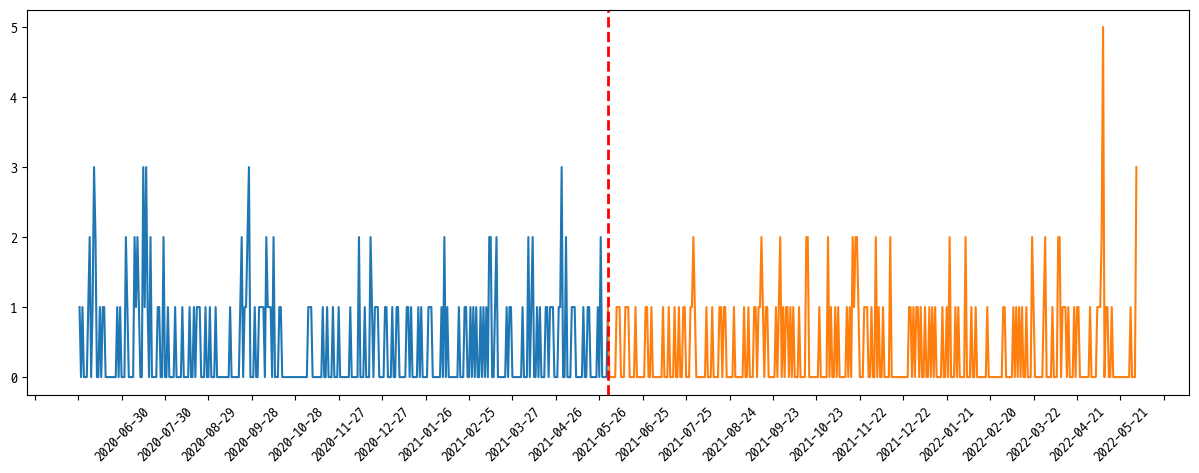

In [68]:
import matplotlib.dates as mdates
plt.figure(figsize = (15,5))
month = mdates.DayLocator(interval=30)  # 한 주마다 눈금 설정
plt.gca().xaxis.set_major_locator(month)

plt.plot(acc_only['date'][:366].values, acc_only['사고건수'][:366].values)
plt.plot(acc_only['date'][365:].values, acc_only['사고건수'][365:].values)
plt.axvline(x=acc_only['date'][365], color='r', linestyle='--', linewidth=2)
plt.xticks(rotation=45)
plt.show()

### Modeling

#### Set Variance

In [69]:
acc1_X = acc1.iloc[:-1,7:]
acc1_Y = acc1.iloc[:-1,6]
acc2_X = acc2.iloc[:-1,7:]
acc2_Y = acc2.iloc[:-1,6]

#### Sequence

In [70]:
acc1_X_Seq, acc1_Y_Seq, acc2_X_Seq, acc2_Y_Seq = [],[],[],[]

m = 30

for i in range(len(acc1_X) - m):
    acc1_X_Seq.append(acc1_X.iloc[i : i+m])
    acc1_Y_Seq.append(acc1_Y.iloc[i+m])

acc1_X_Seq, acc1_Y_Seq = np.array(acc1_X_Seq), np.array(acc1_Y_Seq)

for i in range(len(acc2_X) - m):
    acc2_X_Seq.append(acc2_X.iloc[i : i+m])
    acc2_Y_Seq.append(acc2_Y.iloc[i+m])

acc2_X_Seq, acc2_Y_Seq = np.array(acc2_X_Seq), np.array(acc2_Y_Seq)
    

#### Model Produce

In [71]:
# model1 = tf.keras.models.Sequential([
#     tf.keras.layers.LSTM(64, activation='relu', input_shape=(acc1_X_Seq.shape[1], acc1_X_Seq.shape[2])),
#     tf.keras.layers.Dense(1)
# ])

# # complie
# model1.compile(optimizer='adam', loss='mean_squared_error')

# model2 = tf.keras.models.Sequential([
#     tf.keras.layers.LSTM(64, activation='relu', input_shape=(acc2_X_Seq.shape[1], acc2_X_Seq.shape[2])),
#     tf.keras.layers.Dense(1)
# ])

# # complie
# model2.compile(optimizer='adam', loss='mean_squared_error')


model1 = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, activation='relu', input_shape=(acc1_X_Seq.shape[1], acc1_X_Seq.shape[2]), kernel_initializer=glorot_uniform()),
    tf.keras.layers.Dense(32, activation='relu', kernel_initializer=glorot_uniform()),
    tf.keras.layers.Dense(1),
])

# complie
model1.compile(optimizer='adam', loss='mean_squared_error')


model2 = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, activation='relu', input_shape=(acc2_X_Seq.shape[1], acc2_X_Seq.shape[2])),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1),
  
])

# complie
model2.compile(optimizer='nadam', loss='mean_squared_error')

In [72]:
model1.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 64)                22016     
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 1)                 33        
                                                                 
Total params: 24129 (94.25 KB)
Trainable params: 24129 (94.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [73]:
model2.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_5 (LSTM)               (None, 64)                22016     
                                                                 
 dense_10 (Dense)            (None, 32)                2080      
                                                                 
 dense_11 (Dense)            (None, 1)                 33        
                                                                 
Total params: 24129 (94.25 KB)
Trainable params: 24129 (94.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


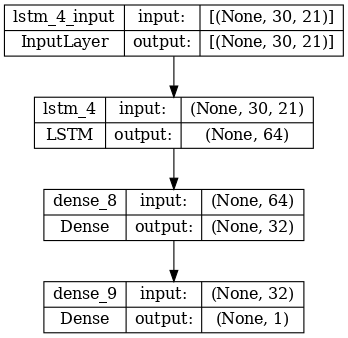

In [74]:
plot_model(model1,show_shapes=True,dpi=80)

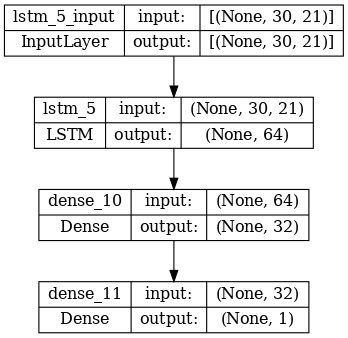

In [75]:
plot_model(model2,show_shapes=True,dpi=80)

### Fitting

In [76]:
acc1_X_train, acc1_y_train = acc1_X_Seq[:365, :], acc1_Y_Seq[:365]
acc2_X_train, acc2_y_train = acc2_X_Seq[:365, :], acc2_Y_Seq[:365]

model1.fit(acc1_X_train, acc1_y_train, epochs = 20, batch_size = 256, validation_split = 0.2)
model2.fit(acc2_X_train, acc2_y_train, epochs = 20, batch_size = 256, validation_split = 0.2)

Epoch 1/20
2/2 [==============================] - 1s 196ms/step - loss: 0.4713 - val_loss: 0.4304
Epoch 2/20
2/2 [==============================] - 0s 38ms/step - loss: 0.4491 - val_loss: 0.4048
Epoch 3/20
2/2 [==============================] - 0s 40ms/step - loss: 0.4359 - val_loss: 0.3995
Epoch 4/20
2/2 [==============================] - 0s 36ms/step - loss: 0.4204 - val_loss: 0.3971
Epoch 5/20
2/2 [==============================] - 0s 43ms/step - loss: 0.4089 - val_loss: 0.3930
Epoch 6/20
2/2 [==============================] - 0s 49ms/step - loss: 0.4037 - val_loss: 0.3845
Epoch 7/20
2/2 [==============================] - 0s 57ms/step - loss: 0.3956 - val_loss: 0.3728
Epoch 8/20
2/2 [==============================] - 0s 43ms/step - loss: 0.3889 - val_loss: 0.3664
Epoch 9/20
2/2 [==============================] - 0s 38ms/step - loss: 0.3968 - val_loss: 0.3662
Epoch 10/20
2/2 [==============================] - 0s 36ms/step - loss: 0.3898 - val_loss: 0.3710
Epoch 11/20
2/2 [===========

#### Predict

In [77]:
# 예측 loop
num_predictions = 365     # 예측할 시점 수
predictions_per_step = 5  # 한 번에 예측할 건수
acc1_y_pred = []               # 예측 값
acc2_y_pred = []               # 예측 값

for i in tqdm(range(num_predictions // predictions_per_step)):
    start_idx = num_predictions - m + i * predictions_per_step
    end_idx = start_idx + predictions_per_step
    
    input_data = acc1_X_Seq[start_idx:end_idx]  # 입력 데이터 선택
    next_step_preds = model1.predict(input_data)  # 예측 수행

    # 예측값 반올림 -> 정수 변환
    next_step_preds_int = next_step_preds.round().astype(int)
    
    acc1_y_pred.extend(next_step_preds_int.reshape(-1))
    
    # 모델 업데이트를 위해 예측값을 y_sequence에 추가
    acc1_Y_Seq[start_idx:end_idx] = next_step_preds_int.reshape(-1)
    
    # 모델 재훈련
    acc1_X_train, acc1_y_train = acc1_X_Seq[:365 + (i + 1) * predictions_per_step, :], acc1_Y_Seq[:365 + (i + 1) * predictions_per_step]
    model1.fit(acc1_X_train, acc1_y_train, epochs=20, batch_size=256, validation_split=0.2, verbose = 0)

print('Model1 Train-Predict End')

for i in tqdm(range(num_predictions // predictions_per_step)):
    start_idx = num_predictions - m + i * predictions_per_step
    end_idx = start_idx + predictions_per_step
    
    input_data = acc2_X_Seq[start_idx:end_idx]  # 입력 데이터 선택
    next_step_preds = model1.predict(input_data)  # 예측 수행

    # 예측값 반올림 -> 정수 변환
    next_step_preds_int = next_step_preds.round().astype(int)
    
    acc2_y_pred.extend(next_step_preds_int.reshape(-1))
    
    # 모델 업데이트를 위해 예측값을 y_sequence에 추가
    acc2_Y_Seq[start_idx:end_idx] = next_step_preds_int.reshape(-1)
    
    # 모델 재훈련
    acc2_X_train, acc2_y_train = acc2_X_Seq[:365 + (i + 1) * predictions_per_step, :], acc2_Y_Seq[:365 + (i + 1) * predictions_per_step]
    model2.fit(acc2_X_train, acc2_y_train, epochs=20, batch_size=256, validation_split=0.2, verbose = 0)
print('Model2 Train-Predict End')

  0%|          | 0/73 [00:00<?, ?it/s]

1/1 [==============================] - 0s 32ms/step
Model1 Train-Predict End


  0%|          | 0/73 [00:00<?, ?it/s]

1/1 [==============================] - 0s 25ms/step
Model2 Train-Predict End


In [78]:
acc1.loc[366:,'acc_pred'] = acc1_y_pred
acc2.loc[366:,'acc_pred'] = acc2_y_pred

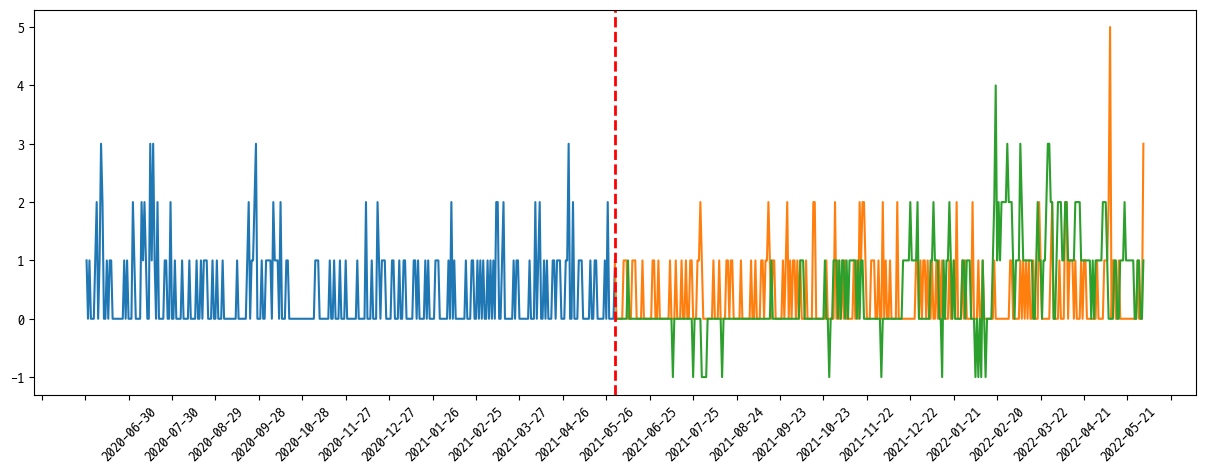

In [79]:
plt.figure(figsize = (15,5))
month = mdates.DayLocator(interval=30)  # 한 주마다 눈금 설정
plt.gca().xaxis.set_major_locator(month)

plt.plot(acc1['date'][:366].values, acc1['사고건수'][:366].values)
plt.plot(acc1['date'][365:].values, acc1['사고건수'][365:].values)
plt.plot(acc1['date'][365:].values, acc1['acc_pred'][365:].values)
plt.axvline(x=acc['date'][365], color='r', linestyle='--', linewidth=2)
plt.xticks(rotation=45)

plt.show()

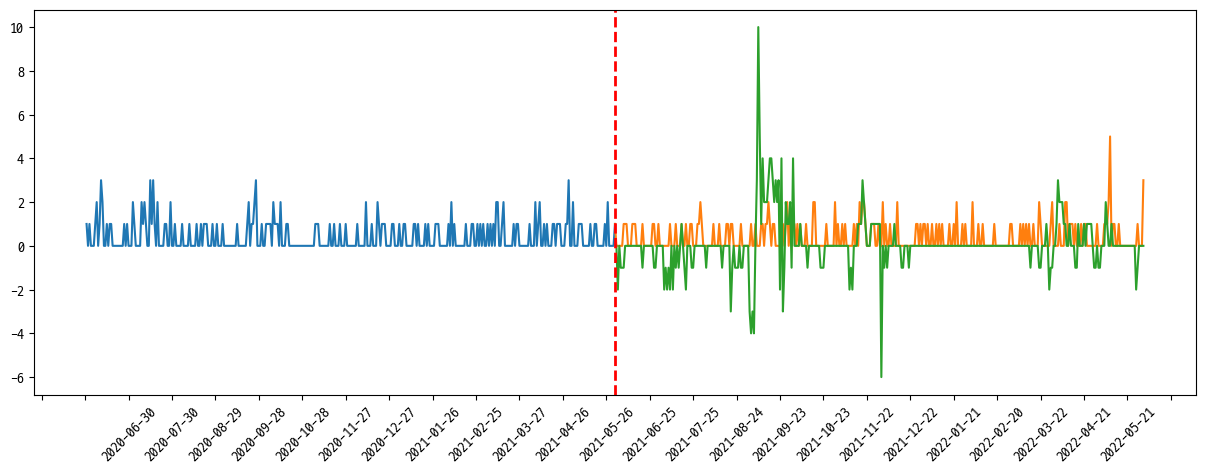

In [80]:
plt.figure(figsize = (15,5))
month = mdates.DayLocator(interval=30)  # 한 주마다 눈금 설정
plt.gca().xaxis.set_major_locator(month)

plt.plot(acc2['date'][:366].values, acc2['사고건수'][:366].values)
plt.plot(acc2['date'][365:].values, acc2['사고건수'][365:].values)
plt.plot(acc2['date'][365:].values, acc2['acc_pred'][365:].values)
plt.axvline(x=acc['date'][365], color='r', linestyle='--', linewidth=2)
plt.xticks(rotation=45)

plt.show()

In [37]:
# 정규화 모듈

def target_type_range(target_df, target_type):
    target_df = df
    if target_type == 'accident':
        return 

def scale_chs(target_df, x_range, scaler_type):
    df = target_df
    df.columns = df.columns.astype(str)
    x_range = x_range
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    elif scaler_type == 'maxabs':
        scaler = MaxAbsScaler()
    df.iloc[:, x_range]= scaler.fit_transform(df.iloc[:, x_range])
    return df

def set_seq(target_df,period,):
    df = target_df
    x_seq, y_seq = [], []
    m = period
    for i in range(len(df) - m):
        acc1_X_Seq.append(df.iloc[i : i+m])
        acc1_Y_Seq.append(df.iloc[i+m])
    x_seq, y_seq = np.array(x_seq), np.array(y_seq)
    return x_seq, y_seq

In [55]:
df = pnt_raw[pnt_raw['equ_idx'] == 'G8647']
df.reset_index(drop=True,inplace=True)

In [56]:
scaled_df = scale_chs(target_df=df, x_range=range(7, df.shape[1]), scaler_type='standard')